# **`Mục 1 — CHUẨN BỊ CHO HỌC MÁY`**

**Mục tiêu**:
- Load dữ liệu đã tiền xử lý
- Kiểm tra nhanh dữ liệu đầu vào cho Học máy
---

# 1.1. Load dữ liệu đã tiền xử lý

Ta sẽ load toàn bộ dữ liệu đã được xử lý và lưu trong thư mục `data/processed/`.

Cụ thể:
- `X_train.npy`, `X_val.npy`, `X_test.npy`: các ma trận đặc trưng sau khi đã được tiền xử lý.
- `y_train.csv`, `y_val.csv`, `y_test.csv`: nhãn giá nhà tương ứng.
- `feature_info.json`: file chứa danh sách tên các feature sau xử lý.
- `preprocessor.pkl`: pipeline xử lý dữ liệu đã lưu từ bước preprocessing (nếu cần sử dụng lại).

Việc load dữ liệu đúng và đầy đủ là bước đầu tiên đảm bảo quy trình học máy hoạt động chính xác.


#### import thư viện

In [1]:
import numpy as np
import pandas as pd
import json
import joblib
from pathlib import Path

#### Định nghĩa đường dẫn tới thư mục data đã xử lý

In [8]:
import os
project_dir = r"d:\Python\MachineLearning\house-price-predict"

os.chdir(project_dir)

print("Đường dẫn hiện tại:", os.getcwd())
print("Các file trong data/processed:", os.listdir("data/processed"))

Đường dẫn hiện tại: d:\Python\MachineLearning\house-price-predict
Các file trong data/processed: ['engineered_dataset.csv', 'feature_info.json', 'X_preprocessed.npy', 'X_test.npy', 'X_train.npy', 'X_val.npy', 'y.csv', 'y_test.csv', 'y_train.csv', 'y_val.csv']


In [9]:
DATA_DIR = Path("data/processed")

#### Load feature names

In [12]:
with open(DATA_DIR / "feature_info.json", "r", encoding="utf-8") as f:
    feature_info = json.load(f)
    feature_names = feature_info

#### Load X data

In [13]:
X_train = np.load(DATA_DIR / "X_train.npy")
X_val   = np.load(DATA_DIR / "X_val.npy")
X_test  = np.load(DATA_DIR / "X_test.npy")

#### Load y data

In [14]:
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["price"].values
y_val   = pd.read_csv(DATA_DIR / "y_val.csv")["price"].values
y_test  = pd.read_csv(DATA_DIR / "y_test.csv")["price"].values

#### Load preprocessor

In [15]:
preprocessor_path = Path("models/preprocessor.pkl")
preprocessor = None
if preprocessor_path.exists():
    preprocessor = joblib.load(preprocessor_path)
    print("Loaded preprocessor.pkl")

print("Dữ liệu đã được load thành công!")

Loaded preprocessor.pkl
Dữ liệu đã được load thành công!


# 1.2. Kiểm tra nhanh dữ liệu đầu vào cho học máy

Mục tiêu:
1. Kiểm tra kích thước của các tập dữ liệu:
   - `X_train`, `X_val`, `X_test`
   - `y_train`, `y_val`, `y_test`
2. Đảm bảo số mẫu giữa X và y khớp nhau.
3. Kiểm tra xem có NaN còn sót lại không.
4. Kiểm tra phân phối biến mục tiêu `Price` để hiểu rõ dữ liệu đầu vào.

Việc kiểm tra này giúp ta xác minh:
- Không có lỗi khi load dữ liệu.
- Không có lỗi tiền xử lý.
- Dữ liệu sẵn sàng đưa vào mô hình học máy.


#### Kiểm tra kích thước

In [16]:
print("* Kích thước X/y:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test:", y_test.shape)

* Kích thước X/y:
X_train: (21156, 398)
y_train: (21156,)
X_val:   (4533, 398)
y_val:   (4533,)
X_test:  (4534, 398)
y_test: (4534,)


#### Kiểm tra NaN

In [17]:
print("\n* Kiểm tra NaN:")
print("NaN trong X_train:", np.isnan(X_train).sum())
print("NaN trong y_train:", np.isnan(y_train).sum())


* Kiểm tra NaN:
NaN trong X_train: 0
NaN trong y_train: 0


---
## Nhận xét:
### ✔️ Dữ liệu đã được load đầy đủ và chính xác

Các file dữ liệu `.npy` và `.csv` đã được tải thành công, với kích thước như sau:

- **Train set:**  
  - X_train: (21156, 398)  
  - y_train: (21156,)

- **Validation set:**  
  - X_val: (4533, 398)  
  - y_val: (4533,)

- **Test set:**  
  - X_test: (4534, 398)  
  - y_test: (4534,)

Điều này cho thấy:
- Dữ liệu đã được chia theo đúng tỷ lệ.  
- Không có sự lệch hoặc mất mẫu giữa X và y.  
- Số lượng feature sau tiền xử lý là **398**, khá lớn, cho thấy data đã trải qua nhiều bước mã hóa & biến đổi đặc trưng.

---

### ✔️ Không còn giá trị thiếu (NaN)

Kết quả kiểm tra NaN:

- NaN trong X_train: **0**  
- NaN trong y_train: **0**

Điều này khẳng định quá trình tiền xử lý đã xử lý sạch missing values và dữ liệu hoàn toàn sẵn sàng cho bước huấn luyện mô hình.

---

# 2.1. Kiểm tra phân phối biến Price (y_train)

Phân phối dữ liệu giá nhà rất quan trọng để:
- Biết dữ liệu có bị lệch (skewed) hay không.
- Xác định các mô hình phù hợp (Linear Regression thường nhạy với skewness).
- Hỗ trợ đánh giá baseline và chất lượng mô hình.


#### Thống kê phân phối y_train

In [19]:
print("Min:", y_train.min())
print("Max:", y_train.max())
print("Mean:", y_train.mean())
print("Median:", np.median(y_train))
print("25%:", np.percentile(y_train, 25))
print("75%:", np.percentile(y_train, 75))

Min: 1.0
Max: 11.5
Mean: 5.873305917942901
Median: 5.9
25%: 4.2
75%: 7.55


#### Ta vẽ biểu đồ Histogram cho `y_train`.

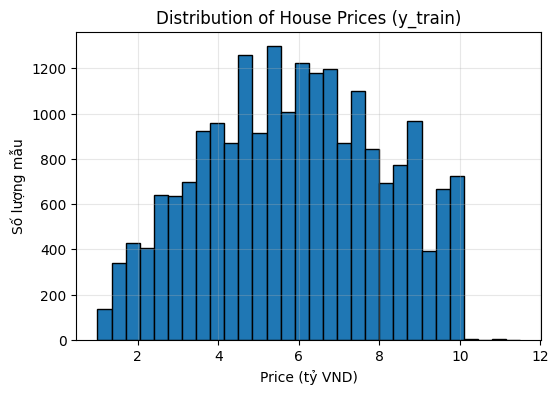

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(y_train, bins=30, edgecolor='black')
plt.title("Distribution of House Prices (y_train)")
plt.xlabel("Price (tỷ VND)")
plt.ylabel("Số lượng mẫu")
plt.grid(alpha=0.3)
plt.show()


---
### **Nhận xét quan trọng:**
- Biểu đồ histogram cho thấy phân phối giá nhà khá **đều và tự nhiên**, trải dài từ 1 → 11.5 tỷ.
- Dữ liệu không bị lệch nghiêm trọng (skewed) như những tập giá nhà thông thường.
- Mean ≈ Median → phân phối khá cân bằng.
- Khoảng giá tập trung chủ yếu trong vùng **4–8 tỷ**, tương ứng với phân vị 25–75%.

### **Ý nghĩa đối với mô hình:**
- Linear Regression có khả năng hoạt động tốt vì phân phối không quá lệch.
- Các thuật toán dựa trên khoảng cách như KNN cũng phù hợp vì dữ liệu khá phân tán đều.
- Không có outlier quá lớn → giảm nguy cơ mô hình bị nhiễu.
---

# 1.3. Định nghĩa bài toán & lựa chọn metric

Trong dự án này, ta thực hiện **hai bài toán học máy**:

## 1.3.1. Bài toán Hồi quy (Regression)
**Mục tiêu:** Dự đoán giá nhà (`Price`), là biến liên tục.

### Các metric sử dụng:
- **MSE (Mean Squared Error)**  
  Phạt sai số lớn rất mạnh.
- **RMSE (Root MSE)**  
  Đơn vị giống với giá trị thực → dễ giải thích.
- **MAE (Mean Absolute Error)**  
  Trung bình khoảng sai số tuyệt đối.
- **R² Score**  
  Đo mức độ mô hình giải thích được phương sai dữ liệu.

---

## 1.3.2. Bài toán Phân lớp (Classification)
**Mục tiêu:** Dự đoán nhóm giá nhà:
- **Low**
- **Medium**
- **High**

Các nhóm sẽ được tạo từ giá `Price`.

### Các metric sử dụng:
- **Accuracy** – Tỷ lệ dự đoán đúng.
- **Precision** – Mức độ chính xác của dự đoán.
- **Recall** – Mức độ bắt được các mẫu đúng.
- **F1-score** – Trung hoà Precision và Recall.
- **Confusion Matrix** – Ma trận so sánh dự đoán vs thực tế.

---


### Nhận xét: 
#### Dựa trên mục tiêu dự án, ta triển khai song song **hai bài toán học máy**:

### **(1) Hồi quy – Dự đoán giá nhà (Price)**
- Biến mục tiêu liên tục.
- Metric lựa chọn:
  - **MAE**
  - **MSE**
  - **RMSE**
  - **R²**

→ Đây là bộ metric tiêu chuẩn cho bài toán regression, đảm bảo đánh giá mô hình đa chiều.

### **(2) Phân lớp – Dự đoán nhóm giá (Low/Medium/High)**
- Giá nhà được chia nhóm dựa trên khoảng giá.
- Metric lựa chọn:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score (macro)**
  - **Confusion Matrix**

→ Bộ metric phù hợp cho bài toán multi-class classification và cho phép đánh giá từng lớp một cách cân bằng.

---